# **Лекция 1.3. Множества и словари**

In [2]:
import pandas as pd

In [ ]:
df = 

## **§1. Тип set. Множества и работа с ними**
**Множество** --- это контейнер, в котором порядок элементов не сохраняется и даже может изменяться, но многие операции происходят очень быстро и естественно.

Создать множество можно при помощи перечисления значений через запятую в фигурных скобках:

In [1]:
the_set = {2, 3, 5, 7, 11, 13, 17, 19, 7, 5}
print(the_set, type(the_set), len(the_set))

{2, 3, 5, 7, 11, 13, 17, 19} <class 'set'> 8


Или при помощи конструктора set:

In [2]:
the_set = set(range(10, 100, 10))
print(the_set, type(the_set), len(the_set))

{70, 40, 10, 80, 50, 20, 90, 60, 30} <class 'set'> 9


Как и в математике, в Python есть пустое множество:

In [3]:
the_set = set()
print(the_set, type(the_set), len(the_set))

set() <class 'set'> 0


Элемент не может входить в множество дважды или более. Любое значение либо входит в множество, либо не входит в него. В результате, в отличие от списка, все значения в множестве уникальны:

In [4]:
the_list = [5, 7, 8, 6, 9,1, 2, 3, 4, 8, 7, 6, 5, 4, 3, 2, 1, 5, 2, 20, 10, 5, 15, 50]
the_set = set(the_list)
print(the_set)

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 50, 20}


Множества в Python отражают математический концепт множества, однако применяют их не только математики. Например, биологи всё время работают с *множествами животных и растений*.

### **1.1 Простая задача для биолога**

Итак, у биолога есть файл  `plants.txt` с названиями растений --- каждое в новой строке. Однако, много строк в файле повторяются. Биолог хочет узнать сколько в этой базе уникальных названий растений.

In [5]:
with open('plants.txt', encoding='utf8') as file:
    plants = set(line.strip() for line in file) #line.strip вернет копию строки  с удаленными начальными и конечными символами chars. Другими словами, обрежет строку str с обоих концов.
    print(plants, len(plants))

FileNotFoundError: [Errno 2] No such file or directory: 'plants.txt'

В примере выше можно увидеть, что названия растений идут в каком-то странном порядке --- не по алфавиту (лексикографически) и не в оригинальном порядке их добавления в множество. Увы, это то, чем приходится расплачиваться за *скорость поиска в множестве*.

### **1.2 Множество — итерируемый объект**
Элементы множества можно перебирать циклом for, его можно распаковывать или отдавать в функции конвейерной обработки.

In [ ]:
i=1
for plant in plants:
    print("Растение",i,":", plant)
    i+=1

In [ ]:
print(*plants, sep='; ')
print(type(plants), type(plant))

Напечатать с большой буквы растения, у которых последняя буква "а":

In [ ]:
print(*map(lambda plant: plant.title(), filter(lambda plant: plant[-1] == 'а', plants)))

### **1.3 Принадлежность множеству**
В математике для указания того, что элемент принадлежит множеству есть нотация $x \in A$, что не принадлежит: $y \notin A$

Для проверки, принадлежит элемент множеству или нет, есть две операции: `in` и `not in`.

Результат их логический --- правда или ложь, а значит их можно использовать в циклах `while` и ветвлениях `if`:

In [ ]:
plants.add("сосна")
x=input("Введите поиск:")
if x.lower() in plants:
    print(f"{x} есть в этом множестве растений!")
elif x not in plants:
    print("Этого растения в множестве нет...")
else:
    print("Третьего не дано. Этот print никогда не случится.")

### **1.4 Сравнение множеств**
В математике множество, все элементы которого содержатся в другом множестве, называется подмножеством, вложенным в это множество.
В Python для проверки отношения вложенности между множествами есть оператор сравнения <=.


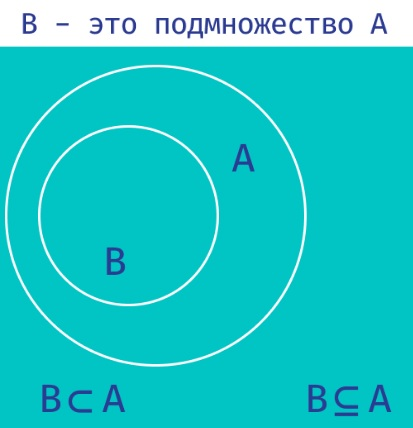

In [ ]:
plants = {"береза", "липа", "дуб", "клен","сосна","ромашка", "роза", "мак", "ландыш"}
tree_plants = {"береза", "липа", "дуб", "клен","сосна"}
flowers = {"ромашка", "роза", "мак", "ландыш", "липа"}

if flowers <= plants:
    print("Все цветы являются растениями.")
if plants >= tree_plants:
    print("Все деревья являются растениями.")

Множества, в которых все элементы совпадают, называются эквивалентными множествами. При этом порядок не важен, так как порядка в множестве как бы и нет. Для сравнения на эквивалентность используются операторы "равно" == и "не равно" !=.

In [6]:
if tree_plants == flowers:
    print("'Деревья' и 'цветы' означают один и тот же набор растений.")
if tree_plants != flowers:
    print("'Деревья' и 'цветы' не совпадают по набору растений.")

NameError: name 'tree_plants' is not defined

Также есть операторы > и <, которые означают вложенность без эквивалентности:

In [ ]:
if plants > tree_plants:
    print("Все деревья являются растениями. При этом растений больше, чем деревьев.")

Рассмотрим такой пример:

In [ ]:
if flowers > tree_plants:
    print('Цветы - строгое надмножество деревьев.')
elif flowers < tree_plants:
    print('Цветы - строгое подмножество деревьев.')
elif flowers == tree_plants:
    print('Цветы и деревья - эквивалентные множества.')
else:
    print("Казалось бы, такого не может быть...")

Разве может быть, что один объект не больше, не меньше и не равен другому?
С числами, строками и многими другими элементами так просто не может быть... А с множествами может!

Для множеств в Python  нет отношения порядка, и *сортировать список множеств бесполезно*.

### **1.5 Опенации над множестами**

**Пересечение множеств**
Множество элементов, которые находятся хотя бы в одном из двух множеств, в математике называется объединением множеств.
Множество элементов, которые одновременно находятся в первом и втором множествах, в математике называется *пересечением множеств*. В Python операция *пересечение множеств* реализована при помощи метода `intersection`, но также можно пользоваться оператором `&`:

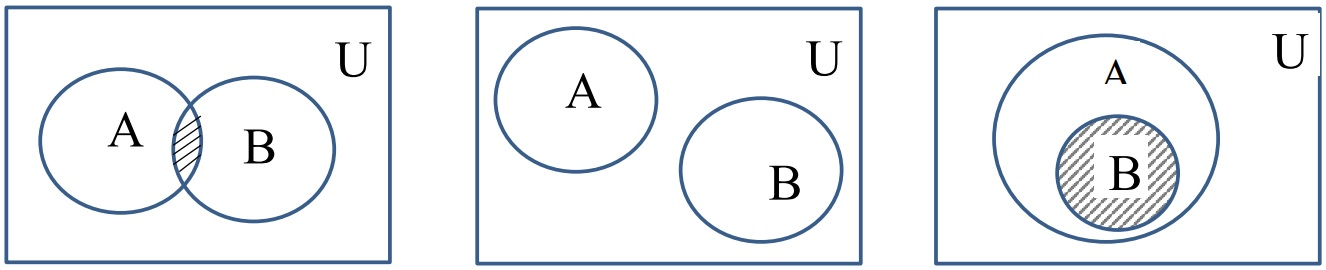

In [ ]:
flowers.intersection(tree_plants)

Или:

In [ ]:
flowers & tree_plants

**Объединение множеств**
Множество элементов, которые находятся хотя бы в одном из двух множеств, в математике называется объединением множеств.
В Python операция объединение множеств реализована при помощи метода union, но также можно пользоваться оператором |:

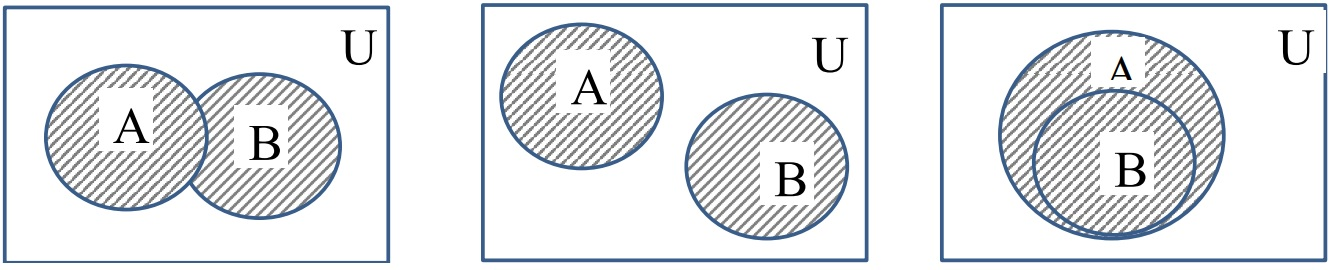

In [ ]:
flowers.union(tree_plants)

Или:

In [ ]:
flowers | tree_plants

**Разность множеств**
Также есть возможность вычитать множества, понимая под этим множество элементов первого множества, которые не являются при этом элементами второго множества.
Операции объединения и пересечения симметричны, т.е. не важно какое множество слева, а какое справа. В случае разности множеств это принципиально важно:

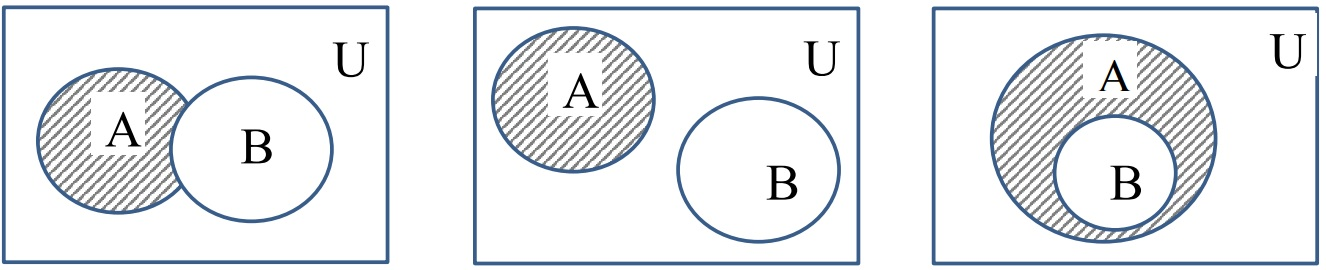

In [ ]:
flowers - tree_plants

In [ ]:
flowers.difference(tree_plants)

In [ ]:
tree_plants - flowers

In [ ]:
tree_plants.difference(flowers)

В математике есть ещё одна интересная операция с двумя множествами — **симметрическая разность**. По сути это объединение двух множеств за исключением их пересечения. Ещё раз: из объединения исключаются те элементы, которые принадлежат сразу двум множествам. В Python эта операция вызывается методом множества symmetric_difference или оператором ^:

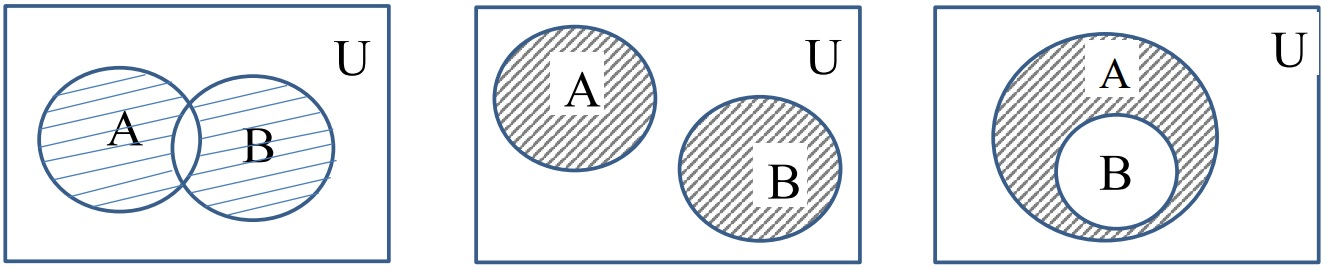

In [ ]:
flowers.symmetric_difference(tree_plants)

In [7]:
flowers ^ tree_plants

NameError: name 'flowers' is not defined

### **1.6 Set comprehensions: генерация множеств**
Так же, как и списки, множества можно генерировать на основании итерируемых объектов.

In [ ]:
inverted_plants_names = {name[::-1] for name in plants}
print(inverted_plants_names)

**Добавление** элементов в множество и удаление их из него

Надо заметить, что все вышеперечисленные операции не изменяют старые, а создают новое множество.

Тем не менее, в Python множество --- это изменяемый объект. В него можно добавлять элементы и удалять их, причём делать это как с одним значением, так и с целым набором

In [ ]:
my_garden = {"липа", "береза", "роза", "ромашка", "ландыш"}
print(id(my_garden), my_garden)
my_garden.add('лаванда')
print(id(my_garden), my_garden)

In [ ]:
my_garden = {"липа", "береза", "роза", "ромашка", "ландыш"}
print(id(my_garden), my_garden)
some_new_plants = ["вишня", "яблоня", "смородина", "роза"]
my_garden.update(some_new_plants)
print(id(my_garden), my_garden)

Обратите внимание ещё раз, что "роза" не вошла в множество второй раз. Вообще добавление в множество уже имеющегося там элемента не приводит к ошибке, но и множество при этом не меняется. Учтите это.

**Удаление элементов**
Удаление remove происходит с генерацией ошибки, если удаляемого элемента в множестве нет, и удалять нечего:

In [ ]:
my_garden = {"липа", "береза", "роза", "ромашка", "ландыш"}
print(my_garden)
my_garden.remove("береза")
print(my_garden)
my_garden.remove("береза") # <--- тут произойдёт ошибка
print(my_garden)

А также молчаливое discard:

In [ ]:
my_garden = {"липа", "береза", "роза", "ромашка", "ландыш"}
print(my_garden)
my_garden.discard("береза")
print(my_garden)
my_garden.discard("береза") # <--- тут не произойдёт ошибка
print(my_garden)

# **§2. Тип dict. Словарь и операции с ним**
**Словарь** похож на множество тем, что хранение в нём не упорядочено, а поиск происходит насколько возможно быстро. Однако хранятся в нём не элементы, а *пары (ключ, значение)*.

Создаётся словарь как и множество --- перечислением в фигурных скобках `{}`, но не элементов, а пар через знак `:`.

In [ ]:
the_dict = {"Казахстан": "Астана","Украина": "Киев","Китай": "Пекин"}
print(type(the_dict))
print(the_dict)

Можно использовать конструктор dict, и дать ему итерируемый объект с парами (ключ, значение). Кстати, сформировать такую последовательность пар поможет функция zip.

In [ ]:
states =  "Казахстан","Украина", "Китай"
capitals =  "Астана","Киев", "Пекин"

for Cuple in zip(states, capitals):
    print(Cuple)
print(type(Cuple))
print('*'*40)

the_dict = dict(zip(states, capitals))
print(the_dict)

Ключи уникальны в рамках словаря, они не могут повторяться. С точки зрения ключей словарь --- это множество. Но при этом каждому ключу сопоставлено значение. Значения не уникальны в рамках словаря, то есть у разных ключей значения могут повторяться. Но у одного ключа всегда только одно значение.

In [ ]:
the_dict = {"корова": 2, "коза":2, "собака": 3, "кошка": 3,
            "рыба": 0, "петух": 8}
print("Угадайте, что значат числа в этой задаче-шутке?")
for key in the_dict:
    print(key, the_dict[key], sep=' - ')

Обратите внимание, что при итерировании по словарю он отдаёт только ключи!

Чтобы получить значение конкретного ключа, нужно обратиться к словарю с квадратными скобками, то есть буквально как к массиву. Только тип key может быть, например, строкой.

Можно обратиться за поиском значения по одному конкретному ключу:

In [ ]:
the_dict["кошка"]

*Если* ключа в словаре не будет, то мы получим ошибку KeyError:

In [ ]:
the_dict["слон"]

Значит, перед тем как обращаться за значением, нужно убедиться, что такой ключ вообще есть в словаре при помощи операций in / not in:

In [ ]:
key = input("Введите название животного, и я скажу вам число, если его знаю: ")
while key not in the_dict:
    key = input("Простите, такого животного нет в моей базе знаний. Ещё раз: ")
print("Число для", key, "-", the_dict[key])

Чтобы добавить новую пару (ключ, значение) в словарь, нужно просто присвоить этому ключу значение:

In [ ]:
the_dict["осёл"] = 2
print("В словаре теперь содержится", len(the_dict), "пар (ключ, значение).")

Повторное присваивание ключу значения может привести к изменению значения, но нового ключа не создаёт:

In [ ]:
the_dict["осёл"] = 3  # ошибки не будет
print("В словаре содержится", len(the_dict), "пар (ключ, значение).")

Чтобы удалить ключ вместе со значением, используется оператор del:

In [ ]:
print("Были числа таких животных:", end=' ')
print(*the_dict, sep=", ")  # разворачиваем как итерируемый объект — получаем только ключи
del the_dict["рыба"]
print("Теперь я знаю числа таких животных:", end=' ')
print(*the_dict, sep=", ")  # разворачиваем как итерируемый объект — получаем только ключи

Можно безопасно добывать значения из словаря при помощи метода get. В этом случае будет возвращаться значение по умолчанию, которое мы укажем вторым параметром:

In [ ]:
key = input()
print("Число для ключа:", the_dict.get(key, "не знаю."))

Для словарей есть dict comprehensions, которые позволяют генерировать словари по любым итерируемым объектам:

In [ ]:
animals_names = ["корова", "коза", "собака", "кошка", "рыба", "петух", "осёл"]
animals_sounds = ["му", "ме", "гав", "мяу", "", "кукареку", "иа"]
the_dict = {animal: len(sound) for animal, sound in zip(animals_names, animals_sounds)}
print("Разгадка задачи-шутки в исходном тексте:")
print(the_dict)

### **2.1 Задача о выборах**
На факультете политологии решили выбрать представителя в студсовет вуза. Голосование
анонимное и открытое: каждый студент мог написать на своём бюллетене фамилию абсолютно любого студента. Для простоты задачи примем, что фамилии студентов на факультете не повторяются.

Данные голосования лежат в файле elections.txt: каждая фамилия в новой строке. При этом среди студентов есть шутники, которые могут вписать несущестующую фамилию , поэтому для отбраковки голосов у вас есть файл students.txt с фамилиями всех студентов курса.

Пришла пора подводить результаты — распечатать рейтинг студентов по убыванию количества голосов, а также определить победителя.

In [ ]:
with open("students.txt", encoding='utf8') as file:
    students_set = {line.strip() for line in file}
print(students_set)

In [ ]:
candidates_votes = {}
with open("elections.txt", encoding='utf8') as file:
    for line in file:
        candidate = line.strip()
        if candidate not in students_set:
            continue
        if candidate not in candidates_votes:
            candidates_votes[candidate] = 1
        else:
            candidates_votes[candidate] += 1
print(candidates_votes)
print(type(candidates_votes), type(students_set))

Метод items возвращает ключи и значения словаря в виде набора кортежей. Результат возвращается в виде специального объекта dict_items.

In [ ]:
candidates_votes = {}  # пустой словарь для пар (кандидат, количество голосов за него)
with open("students.txt", encoding="utf8") as file:
    students_set = {line.strip() for line in file}
with open("elections.txt", encoding="utf8") as file:
    for line in file:
        candidate = line.strip()
        if candidate not in students_set:
            continue  # пропускаем такую фамилию, прыгаем на следующую итерацию цикла for
        if candidate not in candidates_votes:
            candidates_votes[candidate] = 1  # Это первый голос, поданный за этого студента.
        else:
            candidates_votes[candidate] += 1  # За этого кандидата поступил ещё один голос.

rating = sorted(candidates_votes.items(), key=lambda pair: pair[1], reverse=True)
elected_delegate = rating[0][0]
print("Избранный представитель факультета:", elected_delegate)
print()  # представление результатов табличкой:
print("Фамилия кандидата".ljust(30), "Голосов".ljust(10), sep='| ')
print('-'*30 + '+' + '-'*10)
for candidate, votes in rating:
    print(candidate[:30].ljust(30), str(votes).ljust(10), sep='| ')

ljust() вернет новую строку с текстом str , выровненным по левому краю и шириной width.

В случае подсчёта сущностей используем класс Counter из стандартной библиотеки collections.

In [ ]:
from collections import Counter

candidates_votes = Counter()
# Счётчик для голосов за кандидатов.
with open("students.txt", encoding="utf8") as file:
    students_set = {line.strip() for line in file}
with open("elections.txt", encoding="utf8") as file:
    for line in file:
        candidate = line.strip()
        if candidate in students_set:
            candidates_votes[candidate] += 1  # +1 голос за кандидата.

rating = candidates_votes.most_common()
elected_delegate = rating[0][0]
print("Избранный представитель факультета:", elected_delegate)
print()  # представление результатов табличкой:
print("Фамилия кандидата".ljust(30), "Голосов".ljust(10), sep='| ')
print('-'*30 + '+' + '-'*10)
for candidate, votes in rating:
    print(candidate[:30].ljust(30), str(votes).ljust(10), sep='| ')

most_common() возвращает список из n наиболее распространенных элементов и их количество от наиболее распространенных до наименее. Если n опущено или None , метод cnt. most_common() возвращает все элементы в счетчике.